In [1]:
import random
import torch
from d2l import torch as d2l

In [3]:
def synthetic_data(w, b, num_examples):  #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

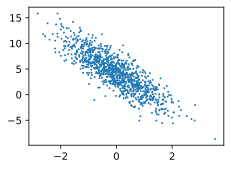

In [4]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

In [ ]:
# 读取数据集函数

def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]




In [6]:
# 定义线性回归模型
def lin(X, w, b):
    return torch.matmul(X, w) + b

In [7]:
# 定义平方损失函数
def loss(y_hat, y):
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [18]:
# 随机梯度下降
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()


In [19]:
# 训练
epochs = 10
lr = 0.01
batch = 10

w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

for epoch in range(epochs):
    for X, y in data_iter(batch, features, labels):
        l = loss(lin(X, w, b), y)
        l.sum().backward()
        sgd([w, b], lr, X.shape[0])
    
    with torch.no_grad():
        train_l = loss(lin(features, w, b), labels)
        print(f'epoch {epoch + 1} : loss {train_l.mean():f}')

epoch 1 : loss 2.249385
epoch 2 : loss 0.313657
epoch 3 : loss 0.044310
epoch 4 : loss 0.006379
epoch 5 : loss 0.000970
epoch 6 : loss 0.000188
epoch 7 : loss 0.000073
epoch 8 : loss 0.000056
epoch 9 : loss 0.000054
epoch 10 : loss 0.000053
